In [17]:
from utils import *


In [18]:
mpp_data = pd.read_json("data/V09372A_mpp_output_default.json")
pss_data = pd.read_json("data/V09372A_pss_output_default.json")

In [19]:
mpp_data.head()

,x,y,z,r,t,dts,E,Esum,ievt_n
0,-36.976525,26.101254,35.791054,45.260787,"[14000000.0, 14000000.0]",1698.808083,324.255313,510.739327,17
1,-35.204680,22.702694,41.826273,41.890115,"[14000000.0, 14000000.0]",1691.245668,186.484014,510.739327,17
2,-4.408933,0.380497,5.291284,4.425321,"[14000000.0, 14000000.0, 14000000.0, 14000000....",1936.495915,95.207061,2345.009424,49
3,-4.188990,0.472103,5.330147,4.215509,"[14000000.0, 14000000.0, 14000000.0, 14000000....",1937.103902,204.116879,2345.009424,49
4,-4.049721,0.514689,5.124283,4.082297,"[14000000.0, 14000000.0, 14000000.0, 14000000....",1938.264531,1005.035297,2345.009424,49


In [20]:
pss_data.head()

,Es,AoEs
0,186.100067,0.841711
1,2345.932129,0.843397
2,804.222229,0.531521
3,583.484985,0.661929
4,950.647949,0.401381


In [5]:
pss_data.shape, mpp_data.ievt_n.nunique()

((30944, 2), 30958)

In [9]:
n_clusters = 4
data_dict = {}

for i in range(n_clusters):
    data_dict[f"E{i}"] = []
    data_dict[f"dt{i}"] = []
data_dict["Esum"] = []
data_dict["ievt_n"] = []

grouped = mpp_data.groupby('ievt_n')

new_indexes = pd.read_csv('data/new_index.csv').Column1.values.astype('int')

# Iterate through each group
for ievt_n, group in grouped:
    if ievt_n in new_indexes: continue
    
    # Get the cluster_energy values for the group
    energies = group['E'].values
    dts = group['dts'].values
    
    # Sort energies in descending order and get the indices
    sorted_indices = np.argsort(energies)[::-1]
    for i in range(n_clusters):
        clust_index = sorted_indices[i] if len(sorted_indices) > i else None
        E_clust = energies[clust_index] if clust_index is not None else 0
        dt_clust = dts[clust_index] if clust_index is not None else 0
        data_dict[f"E{i}"].append(E_clust)
        data_dict[f"dt{i}"].append(dt_clust)
    
    data_dict["Esum"].append(sum(energies))
    data_dict["ievt_n"].append(ievt_n)
    
for key, item in data_dict.items():
    data_dict[key] = np.array(item)
df_mpp_data = pd.DataFrame(data_dict)

In [10]:
df_mpp_data

,E0,dt0,E1,dt1,E2,dt2,E3,dt3,Esum,ievt_n
0,324.255313,1698.808083,186.484014,1691.245668,0.000000,0.000000,0.000000,0.000000,510.739327,17
1,1005.035297,1938.264531,237.690102,1935.968861,213.292507,1940.195841,204.116879,1937.103902,2345.009424,49
2,358.809740,1779.081880,124.975914,1567.746659,96.162107,1573.089634,86.535131,1824.818342,804.326144,56
3,199.035527,1573.530460,196.086003,1543.404316,91.477276,1583.904015,58.570843,1586.748550,583.188122,59
4,341.170990,1832.540177,197.254448,1747.095643,138.970993,1792.237057,114.346371,1874.238776,952.117704,64
...,...,...,...,...,...,...,...,...,...,...
30939,481.852079,1605.528910,128.022535,1592.312940,117.454047,1580.992079,0.000000,0.000000,727.328660,494833
30940,299.544853,1658.619872,113.385964,1597.337692,66.524266,1618.083701,46.721970,1604.726612,583.188122,494836
30941,337.456100,1715.042397,181.195163,1679.221891,179.915047,1716.822330,28.762350,1716.803375,727.328660,494840
30942,883.352085,1571.102759,235.903885,1545.890934,130.825545,1571.447758,107.648832,1603.858241,1500.703728,494868


In [12]:
df_data = pd.concat([pss_data, df_mpp_data], axis=1)
df_data

,Es,AoEs,E0,dt0,E1,dt1,E2,dt2,E3,dt3,Esum,ievt_n
0,186.100067,0.841711,324.255313,1698.808083,186.484014,1691.245668,0.000000,0.000000,0.000000,0.000000,510.739327,17
1,2345.932129,0.843397,1005.035297,1938.264531,237.690102,1935.968861,213.292507,1940.195841,204.116879,1937.103902,2345.009424,49
2,804.222229,0.531521,358.809740,1779.081880,124.975914,1567.746659,96.162107,1573.089634,86.535131,1824.818342,804.326144,56
3,583.484985,0.661929,199.035527,1573.530460,196.086003,1543.404316,91.477276,1583.904015,58.570843,1586.748550,583.188122,59
4,950.647949,0.401381,341.170990,1832.540177,197.254448,1747.095643,138.970993,1792.237057,114.346371,1874.238776,952.117704,64
...,...,...,...,...,...,...,...,...,...,...,...,...
30939,727.849243,0.661129,481.852079,1605.528910,128.022535,1592.312940,117.454047,1580.992079,0.000000,0.000000,727.328660,494833
30940,583.135620,0.526761,299.544853,1658.619872,113.385964,1597.337692,66.524266,1618.083701,46.721970,1604.726612,583.188122,494836
30941,727.713196,0.675660,337.456100,1715.042397,181.195163,1679.221891,179.915047,1716.822330,28.762350,1716.803375,727.328660,494840
30942,1501.711426,0.682961,883.352085,1571.102759,235.903885,1545.890934,130.825545,1571.447758,107.648832,1603.858241,1500.703728,494868


In [13]:
use_indices = np.where(~np.isnan(df_data['AoEs'].values))[0]
use_indices_df = pd.DataFrame(use_indices, columns=["use_indices"])
use_indices_df.to_csv('data/not_nan_indices.csv', index=False)

In [16]:
df_data.loc[use_indices]

,Es,AoEs,E0,dt0,E1,dt1,E2,dt2,E3,dt3,Esum,ievt_n
0,186.100067,0.841711,324.255313,1698.808083,186.484014,1691.245668,0.000000,0.000000,0.000000,0.000000,510.739327,17
1,2345.932129,0.843397,1005.035297,1938.264531,237.690102,1935.968861,213.292507,1940.195841,204.116879,1937.103902,2345.009424,49
2,804.222229,0.531521,358.809740,1779.081880,124.975914,1567.746659,96.162107,1573.089634,86.535131,1824.818342,804.326144,56
3,583.484985,0.661929,199.035527,1573.530460,196.086003,1543.404316,91.477276,1583.904015,58.570843,1586.748550,583.188122,59
4,950.647949,0.401381,341.170990,1832.540177,197.254448,1747.095643,138.970993,1792.237057,114.346371,1874.238776,952.117704,64
...,...,...,...,...,...,...,...,...,...,...,...,...
30939,727.849243,0.661129,481.852079,1605.528910,128.022535,1592.312940,117.454047,1580.992079,0.000000,0.000000,727.328660,494833
30940,583.135620,0.526761,299.544853,1658.619872,113.385964,1597.337692,66.524266,1618.083701,46.721970,1604.726612,583.188122,494836
30941,727.713196,0.675660,337.456100,1715.042397,181.195163,1679.221891,179.915047,1716.822330,28.762350,1716.803375,727.328660,494840
30942,1501.711426,0.682961,883.352085,1571.102759,235.903885,1545.890934,130.825545,1571.447758,107.648832,1603.858241,1500.703728,494868


In [9]:
sel_evts = df_data.query('Es < Esum-5').ievt_n
sel_evts


0            17
10          284
11          313
15          328
17          350
          ...  
30923    494629
30924    494640
30931    494751
30936    494801
30943    494890
Name: ievt_n, Length: 5178, dtype: int64

In [22]:
sel_es = df_data.query('Es < Esum-5').Esum.values - df_data.query('Es < Esum-5').Es.values

Text(0, 0.5, 'Z (mm)')

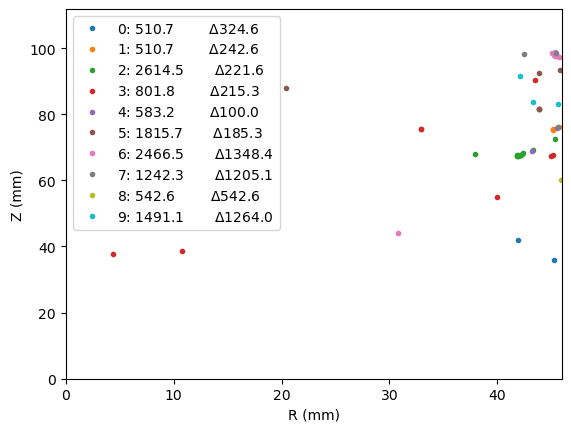

In [31]:
plt.figure()

i = 0
for ievt_n, ediff in zip(sel_evts, sel_es):
    plt.plot(
        mpp_data.query(f'ievt_n == {ievt_n}').r, mpp_data.query(f'ievt_n == {ievt_n}').z, '.',
        label=f'{i}: ' + '{:.1f}'.format(df_data.query('Es < Esum-5').Esum.values[i]) + '\t' + r'$\Delta$' + '{:.1f}'.format(ediff)
    )
    i += 1

    if i == 10: break

plt.xlim(0, 46)
plt.ylim(0, 111.8)
plt.legend()

plt.xlabel('R (mm)')
plt.ylabel('Z (mm)')

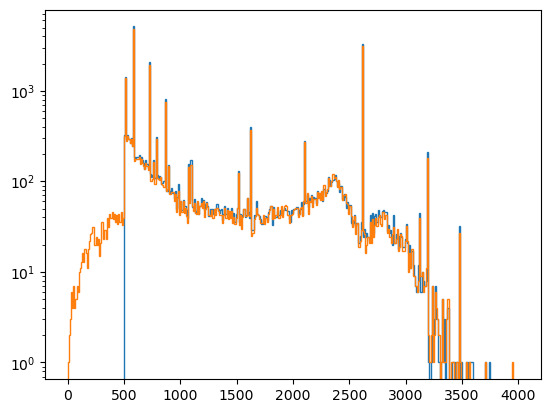

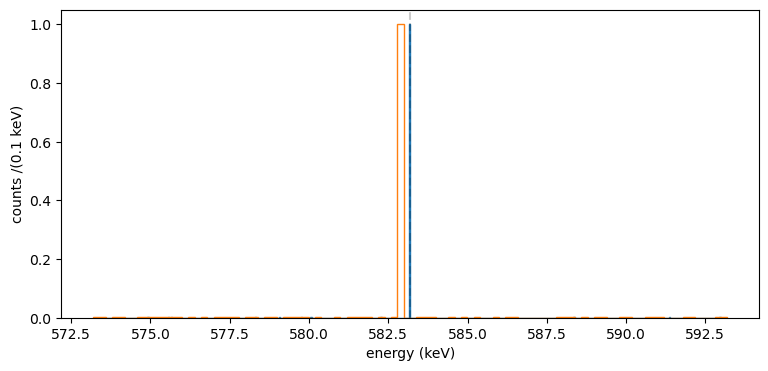

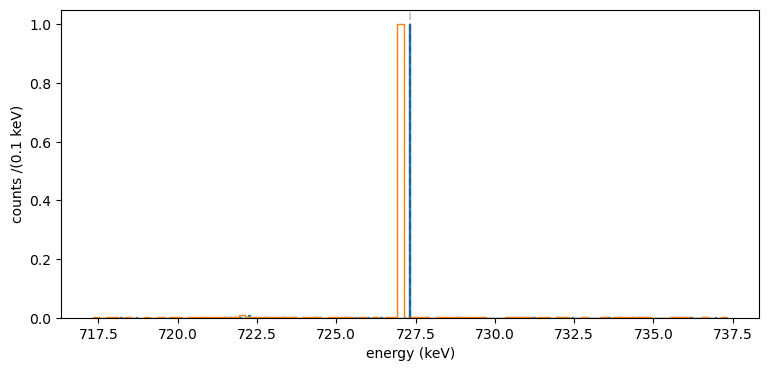

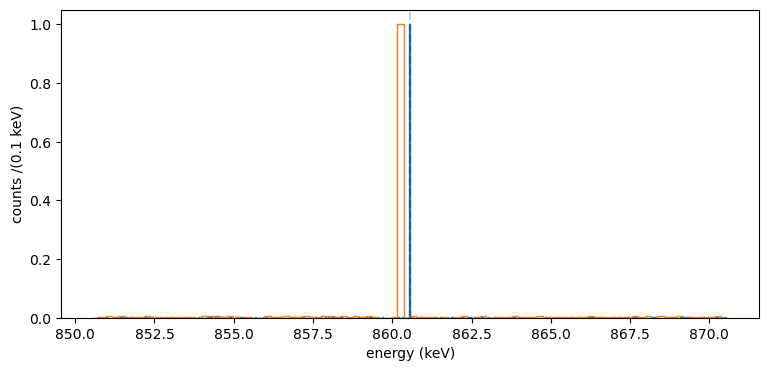

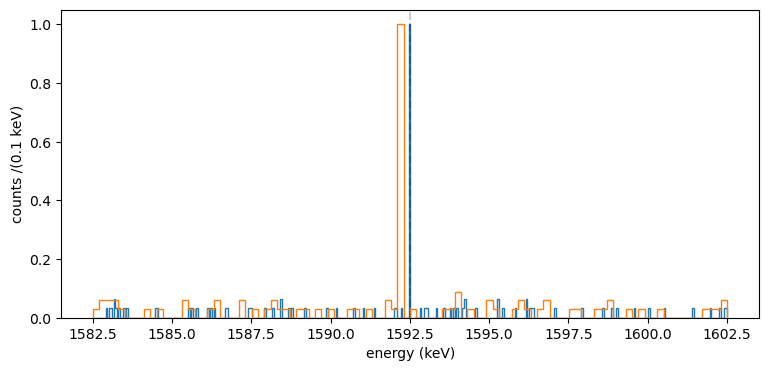

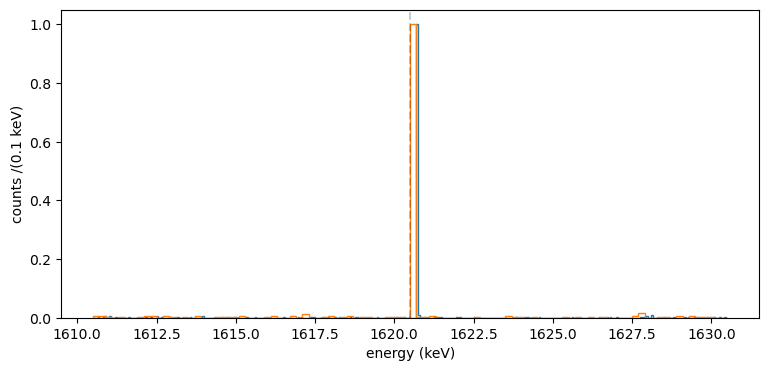

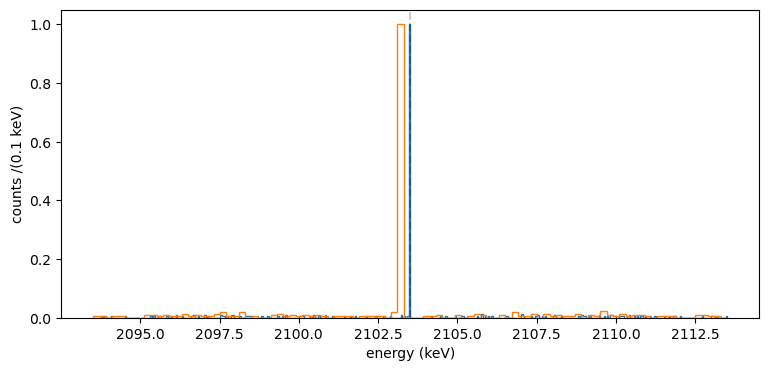

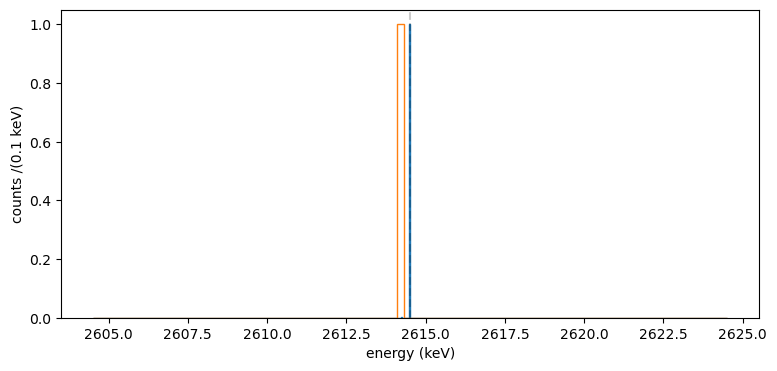

In [38]:
plt.figure()
_ = plt.hist(
    Esum, range=(0,4000), bins=400, histtype='step'
)
_ = plt.hist(
    pss_data['Es'].values, range=(0,4000), bins=400, histtype='step'
)
plt.yscale('log')

peaks = np.array([583.191, 727.330, 860.564, 1592.511, 1620.50, 2103.511, 2614.511])
for i in peaks:
    # plt.axvline(i, ls='--', color='k', alpha=0.2)
    plt.figure(figsize=(9,4))
    plt.axvline(i, ls='--', color='k', alpha=0.2)
    freq, bin_edges = np.histogram(
        Esum[np.where((Esum < i + 10) & (Esum > i - 10))[0]], range=(i-10,i+10), bins=400
    )
    plt.stairs(freq/max(freq), bin_edges)
    freq, bin_edges = np.histogram(
        pss_data.query(f'(Es < {i}+10) & (Es > {i}-10)')['Es'].values, range=(i-10,i+10), bins=100
    )
    plt.stairs(freq/max(freq), bin_edges)
    plt.xlabel('energy (keV)')
    plt.ylabel('counts /(0.1 keV)')

In [19]:
np.where((Esum < i + 15)) 

(array([    0,     3,     6, ..., 30950, 30951, 30954]),)

In [8]:
pss_data.head()

,Es,AoEs
0,186.635010,0.821201
1,3194.914062,0.651846
2,2615.426025,0.782577
3,2343.688477,0.844896
4,803.594177,0.530155


In [47]:
pd.read_json('data/ml_data.json')

,Es,AoEs,E0,dt0,E1,dt1,E2,dt2,E3,dt3,Esum,ievt_n
0,186.100067,0.841711,324.255313,1698.808083,186.484014,1691.245668,0.000000,0.000000,0.000000,0.000000,510.739327,17
1,2345.932129,0.843397,1005.035297,1938.264531,237.690102,1935.968861,213.292507,1940.195841,204.116879,1937.103902,2345.009424,49
2,804.222229,0.531521,358.809740,1779.081880,124.975914,1567.746659,96.162107,1573.089634,86.535131,1824.818342,804.326144,56
3,583.484985,0.661929,199.035527,1573.530460,196.086003,1543.404316,91.477276,1583.904015,58.570843,1586.748550,583.188122,59
4,950.647949,0.401381,341.170990,1832.540177,197.254448,1747.095643,138.970993,1792.237057,114.346371,1874.238776,952.117704,64
...,...,...,...,...,...,...,...,...,...,...,...,...
30939,727.849243,0.661129,481.852079,1605.528910,128.022535,1592.312940,117.454047,1580.992079,0.000000,0.000000,727.328660,494833
30940,583.135620,0.526761,299.544853,1658.619872,113.385964,1597.337692,66.524266,1618.083701,46.721970,1604.726612,583.188122,494836
30941,727.713196,0.675660,337.456100,1715.042397,181.195163,1679.221891,179.915047,1716.822330,28.762350,1716.803375,727.328660,494840
30942,1501.711426,0.682961,883.352085,1571.102759,235.903885,1545.890934,130.825545,1571.447758,107.648832,1603.858241,1500.703728,494868
